# Retail Demand Forecasting Project

In [1]:
import sys
sys.version

'3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]'

In [2]:
import sys
print(sys.executable)

C:\Users\reign\anaconda3\python.exe


## Importing all Necessary Libraries

In [3]:
# !pip install pandas numpy scikit-learn matplotlib seaborn torch mlflow

In [4]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import mlflow
import mlflow.pytorch

import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Loading the Dataset

In [5]:
train = pd.read_csv("train_data.csv")
val = pd.read_csv("validation_data.csv")

In [6]:
train.head()

,store_id,date,sales,customers,promo,school_holiday,store_type,assortment,competition_distance,day_of_week,month,year,week_of_year,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30
0,1,2013-02-06,6140,693,t,f,c,a,1270.0,3,2,2013,6,f,6049,3725,5530,5482.375,5137.258065
1,1,2013-02-07,5499,675,t,f,c,a,1270.0,4,2,2013,6,f,6140,4601,4327,5704.125,5136.258065
2,1,2013-02-08,5681,630,t,f,c,a,1270.0,5,2,2013,6,f,5499,4709,4486,5839.125,5179.935484
3,1,2013-02-09,5370,656,f,f,c,a,1270.0,6,2,2013,6,t,5681,5633,4997,5921.750,5208.451613
4,1,2013-02-11,4409,599,f,f,c,a,1270.0,1,2,2013,7,f,5370,5970,7176,5768.750,5189.483871


In [7]:
val.head()

,store_id,date,sales,customers,promo,school_holiday,store_type,assortment,competition_distance,day_of_week,month,year,week_of_year,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30
0,1,2015-07-01,5223,562,t,f,c,a,1270.0,3,7,2015,27,f,5735,3762,4211,4266.500,4447.967742
1,1,2015-07-02,5558,573,t,f,c,a,1270.0,4,7,2015,27,f,5223,3346,4083,4491.000,4491.419355
2,1,2015-07-03,4665,538,t,f,c,a,1270.0,5,7,2015,27,f,5558,3533,4111,4655.875,4510.193548
3,1,2015-07-04,4797,560,f,f,c,a,1270.0,6,7,2015,27,t,4665,3317,4656,4813.875,4532.322581
4,1,2015-07-06,4359,540,f,f,c,a,1270.0,1,7,2015,28,f,4797,4019,5592,4944.125,4522.741935


In [8]:
print(train.shape)
print(val.shape)

(780754, 19)
(30188, 19)


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780754 entries, 0 to 780753
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   store_id              780754 non-null  int64  
 1   date                  780754 non-null  object 
 2   sales                 780754 non-null  int64  
 3   customers             780754 non-null  int64  
 4   promo                 780754 non-null  object 
 5   school_holiday        780754 non-null  object 
 6   store_type            780754 non-null  object 
 7   assortment            780754 non-null  object 
 8   competition_distance  778739 non-null  float64
 9   day_of_week           780754 non-null  int64  
 10  month                 780754 non-null  int64  
 11  year                  780754 non-null  int64  
 12  week_of_year          780754 non-null  int64  
 13  is_weekend            780754 non-null  object 
 14  lag_1                 780754 non-null  int64  
 15  

In [10]:
val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30188 entries, 0 to 30187
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   store_id              30188 non-null  int64  
 1   date                  30188 non-null  object 
 2   sales                 30188 non-null  int64  
 3   customers             30188 non-null  int64  
 4   promo                 30188 non-null  object 
 5   school_holiday        30188 non-null  object 
 6   store_type            30188 non-null  object 
 7   assortment            30188 non-null  object 
 8   competition_distance  30107 non-null  float64
 9   day_of_week           30188 non-null  int64  
 10  month                 30188 non-null  int64  
 11  year                  30188 non-null  int64  
 12  week_of_year          30188 non-null  int64  
 13  is_weekend            30188 non-null  object 
 14  lag_1                 30188 non-null  int64  
 15  lag_7              

In [11]:
# Converting "date" feature to Date-Time format
train["date"] = pd.to_datetime(train["date"])
val["date"] = pd.to_datetime(val["date"])

- Converted **"date"** to Date-Time format

## Building Baseline Model

In [12]:
# Defining Target
target = "sales"

In [13]:
# Create Baseline Predictions
# Here, Lag 1 is the Baseline Prediction
val["naive_pred"] = val["lag_1"]

In [14]:
rmse_naive = np.sqrt(mean_squared_error(val[target], val["naive_pred"]))
rmse_naive

1930.452350468179

In [15]:
# Dropping "naive_pred"
val = val.drop(columns=["naive_pred"])

In [16]:
val.shape

(30188, 19)

## Building Linear Regression Model

In [17]:
drop_cols = ["sales", "date"]

X_train = train.drop(columns=drop_cols)
y_train = train["sales"]

X_val = val.drop(columns=drop_cols)
y_val = val["sales"]

In [18]:
# Encoding Categorical Features
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)

# Aligning columns in case mismatch
X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)

In [19]:
X_train.isna().sum().sort_values(ascending=False).head(10)

competition_distance    2015
store_id                   0
rolling_30                 0
assortment_c               0
assortment_b               0
store_type_d               0
store_type_c               0
store_type_b               0
school_holiday_t           0
promo_t                    0
dtype: int64

In [20]:
median_distance = X_train["competition_distance"].median()

X_train["competition_distance"] = X_train["competition_distance"].fillna(median_distance)
X_val["competition_distance"] = X_val["competition_distance"].fillna(median_distance)

In [21]:
# Training Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
# Making Predictions
preds = model.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, preds))
rmse_lr

1012.7875752628827

## Building Random Forest Model

In [23]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
# Making Predictions
rf_preds = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, rf_preds))
rmse_rf

695.4392133446282

In [25]:
feature_importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importances.head(15)

customers               0.624683
lag_1                   0.194370
rolling_7               0.039280
day_of_week             0.030733
promo_t                 0.029678
rolling_30              0.027149
store_type_d            0.013868
competition_distance    0.012266
assortment_b            0.005694
store_id                0.005522
week_of_year            0.004927
lag_7                   0.003149
store_type_b            0.002007
lag_30                  0.001809
month                   0.001295
dtype: float64

#### Observation ->
- **Customers** is dominating the table but in real life the model will need to make predictions without customer count since we won't know how many customers will come on a specific day beforehand so the existence of **"customers"** is basically data leakage which should be fixed. Therefore, we will drop it. 

In [26]:
# Dropping "customers"
X_train_no_leak = X_train.drop(columns=["customers"])
X_val_no_leak = X_val.drop(columns=["customers"])

In [27]:
# Re-Training Random Forest
rf2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train_no_leak, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [28]:
# Making Predictions
rf_preds2 = rf2.predict(X_val_no_leak)

rmse_rf2 = np.sqrt(mean_squared_error(y_val, rf_preds2))
rmse_rf2

897.504841685168

### Plotting Distribution of Target Variable (Sales)

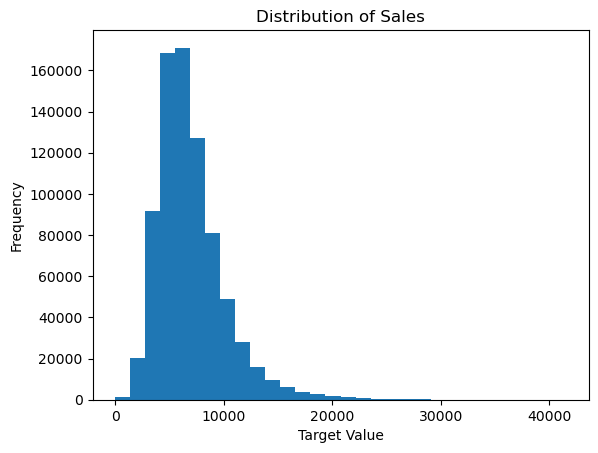

In [29]:
plt.figure()
plt.hist(y_train, bins=30)
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")
plt.show()

- The Target Variable is **Right-Skewed**

In [30]:
# Log transforming the target variable since it's Skewed
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [31]:
# Re-Training Random Forest
rf_log = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_log.fit(X_train_no_leak, y_train_log)

# Making Predictions
log_preds = rf_log.predict(X_val_no_leak)

# Reversing Log Transformation
preds = np.expm1(log_preds)

rmse_log = np.sqrt(mean_squared_error(y_val, preds))
rmse_log

886.2725956247722

## Prepare Data for Sequencing

In [12]:
# Combining Training and Validation data
full_df = pd.concat([train, val], axis=0)
full_df = full_df.sort_values(["store_id", "date"]).reset_index(drop=True)

In [13]:
full_df.shape

(810942, 19)

In [14]:
# Dropping Customers
features_to_drop = ["customers"]
full_df = full_df.drop(columns=features_to_drop)

In [15]:
# Encoding Categorical Features
full_df = pd.get_dummies(full_df, drop_first=True)

In [16]:
full_df.shape

(810942, 21)

In [17]:
full_df.columns

Index(['store_id', 'date', 'sales', 'competition_distance', 'day_of_week',
       'month', 'year', 'week_of_year', 'lag_1', 'lag_7', 'lag_30',
       'rolling_7', 'rolling_30', 'promo_t', 'school_holiday_t',
       'store_type_b', 'store_type_c', 'store_type_d', 'assortment_b',
       'assortment_c', 'is_weekend_t'],
      dtype='object')

In [18]:
# Sorting data based on "date" before dropping it
full_df = full_df.sort_values(["store_id", "date"]).reset_index(drop=True)

In [19]:
# Dropping encoded lag and rolling features since LSTM needs to learn that on it own. Infact feeding those will cause redundancy.
cols_to_drop = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_7',
    'rolling_30'
]

full_df = full_df.drop(columns=cols_to_drop)

In [20]:
full_df.shape

(810942, 16)

In [21]:
# Defining Parameters
SEQUENCE_LENGTH = 30
TARGET_COL = "sales"

In [22]:
# Building Sliding Windows Per Store
X_list = []
y_list = []
dates_list = []

feature_cols = [col for col in full_df.columns if col not in [TARGET_COL, "date"]]

for store_id in full_df["store_id"].unique():
    
    store_df = full_df[full_df["store_id"] == store_id]
    
    data = store_df[feature_cols].values
    target = store_df[TARGET_COL].values
    dates = store_df["date"].values
    
    for i in range(len(store_df) - SEQUENCE_LENGTH):
        X_list.append(data[i:i+SEQUENCE_LENGTH])
        y_list.append(target[i+SEQUENCE_LENGTH])
        dates_list.append(dates[i+SEQUENCE_LENGTH])

X = np.array(X_list)
y = np.array(y_list)
dates_array = np.array(dates_list)

In [23]:
X.shape

(777492, 30, 14)

In [24]:
y.shape

(777492,)

In [27]:
dates_array

array(['2013-03-13T00:00:00.000000000', '2013-03-14T00:00:00.000000000',
       '2013-03-15T00:00:00.000000000', ...,
       '2015-07-29T00:00:00.000000000', '2015-07-30T00:00:00.000000000',
       '2015-07-31T00:00:00.000000000'], dtype='datetime64[ns]')

In [28]:
# os.makedirs("final", exist_ok=True)

# np.save("C:\\Users\\reign\\OneDrive\\Desktop\\All Folders\\1. University Modules Folder\\1. Projects\\retail-demand-forecasting-pipeline\\data\\final\\X.npy", X)
# np.save("C:\\Users\\reign\\OneDrive\\Desktop\\All Folders\\1. University Modules Folder\\1. Projects\\retail-demand-forecasting-pipeline\\data\\final\\y.npy", y)
# np.save("C:\\Users\\reign\\OneDrive\\Desktop\\All Folders\\1. University Modules Folder\\1. Projects\\retail-demand-forecasting-pipeline\\data\\final\\dates_array.npy", dates_array)

In [45]:
# Splitting Train, Validation and Test Set

# Defining split dates
train_split_date = np.datetime64("2015-07-01")
val_split_date   = np.datetime64("2015-07-03")

# Masks
train_idx = dates_array < train_split_date
val_idx   = (dates_array >= train_split_date) & (dates_array < val_split_date)
test_idx  = dates_array >= val_split_date

# Splitting data
X_train_seq = X[train_idx]
y_train_seq = y[train_idx]

X_val_seq = X[val_idx]
y_val_seq = y[val_idx]

X_test_seq = X[test_idx]
y_test_seq = y[test_idx]

In [46]:
X_train_seq.shape

(747304, 30, 14)

In [47]:
X_val_seq.shape

(2229, 30, 14)

In [48]:
X_test_seq.shape

(27959, 30, 14)

In [49]:
X_train_seq = X_train_seq.astype(np.float32)
y_train_seq = y_train_seq.astype(np.float32)

In [50]:
nan_per_feature = np.isnan(X_train_seq).sum(axis=(0,1))
print(nan_per_feature)

[    0 57750     0     0     0     0     0     0     0     0     0     0
     0     0]


In [51]:
X_train_flat = X_train_seq.reshape(-1, 14)
X_val_flat = X_val_seq.reshape(-1, 14)
X_test_flat = X_test_seq.reshape(-1, 14)

In [52]:
imputer = SimpleImputer(strategy="mean")

X_train_flat = imputer.fit_transform(X_train_flat)
X_val_flat = imputer.transform(X_val_flat)
X_test_flat = imputer.transform(X_test_flat)

In [53]:
X_train_seq = X_train_flat.reshape(-1, 30, 14)
X_val_seq = X_val_flat.reshape(-1, 30, 14)
X_test_seq = X_test_flat.reshape(-1, 30, 14)

In [54]:
print(np.isnan(X_train_seq).sum())
print(np.isnan(X_val_seq).sum())
print(np.isnan(X_test_seq).sum())

0
0
0


### Scaling Features and Target Variable

In [55]:
# Scaling Features
scaler = StandardScaler()

# Flattening time dimension to scale features
X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_val_flat   = X_val_seq.reshape(-1, X_val_seq.shape[-1])
X_test_flat  = X_test_seq.reshape(-1, X_test_seq.shape[-1])

# Fitting only on train data
scaler.fit(X_train_flat)

# Transforming and reshaping back to 3D
X_train_scaled = scaler.transform(X_train_flat).reshape(X_train_seq.shape)
X_val_scaled   = scaler.transform(X_val_flat).reshape(X_val_seq.shape)
X_test_scaled  = scaler.transform(X_test_flat).reshape(X_test_seq.shape)

In [56]:
# Scaling the Target variable
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train_seq.reshape(-1,1)).flatten()
y_val_scaled = y_scaler.transform(y_val_seq.reshape(-1,1)).flatten()
y_test_scaled = y_scaler.transform(y_test_seq.reshape(-1,1)).flatten()

In [57]:
X_train_scaled.shape

(747304, 30, 14)

In [58]:
X_val_scaled.shape

(2229, 30, 14)

In [59]:
X_test_scaled.shape

(27959, 30, 14)

## Building LSTM Model with PyTorch

In [60]:
# Setting up Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [61]:
# Creating Custom Dataset Class
class SalesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [62]:
train_dataset = SalesDataset(X_train_scaled, y_train_scaled)
val_dataset = SalesDataset(X_val_scaled, y_val_scaled)
test_dataset = SalesDataset(X_test_scaled, y_test_scaled)

In [63]:
# Creating DataLoader
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [64]:
# Building LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        # The below line can also be written as super().__init__() as preferred in modern PyTorch 
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        
        out, (h_n, c_n) = self.lstm(x)
        
        # Take last time step output
        last_out = out[:, -1, :]
        
        output = self.fc(last_out)
        
        return output.squeeze()

In [65]:
# Initialising Model
INPUT_SIZE = X_train_scaled.shape[2]
HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.0

model = LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

In [66]:
# Defining Loss & Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [67]:
# Creating a Manual Training Loop
EPOCHS = 10
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    
    # Training
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    
    # Validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item() * X_batch.size(0)
    
    val_loss /= len(val_loader.dataset)

    # No Early Stopping implemented here
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_lstm.pth")

    # Code for Early Stopping
    '''
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break
    '''
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")

Epoch [1/10] Train Loss: 0.7360 Val Loss: 0.7565
Epoch [2/10] Train Loss: 0.6896 Val Loss: 0.7367
Epoch [3/10] Train Loss: 0.6681 Val Loss: 0.7790
Epoch [4/10] Train Loss: 0.6484 Val Loss: 0.8214
Epoch [5/10] Train Loss: 0.6326 Val Loss: 0.7867
Epoch [6/10] Train Loss: 0.6210 Val Loss: 0.7334
Epoch [7/10] Train Loss: 0.6053 Val Loss: 0.7559
Epoch [8/10] Train Loss: 0.5924 Val Loss: 0.6781
Epoch [9/10] Train Loss: 0.5683 Val Loss: 0.6497
Epoch [10/10] Train Loss: 0.5466 Val Loss: 0.7643


In [68]:
# Loading the saved Model
model.load_state_dict(torch.load("best_lstm.pth", weights_only=True))

# Making Predictions 
model.eval()

preds = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        
        preds.append(outputs.cpu().numpy())
        actuals.append(y_batch.numpy())

preds = np.concatenate(preds)
actuals = np.concatenate(actuals)

preds = y_scaler.inverse_transform(preds.reshape(-1,1)).flatten()
actuals = y_scaler.inverse_transform(actuals.reshape(-1,1)).flatten()

# Computing RMSE
rmse_lstm = np.sqrt(mean_squared_error(actuals, preds))
rmse_lstm

2266.6228182033287

## Building GRU Model with PyTorch

In [69]:
# Building GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(GRUModel, self).__init__()
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, h_n = self.gru(x)
        
        last_out = out[:, -1, :]
        
        output = self.fc(last_out)
        
        return output.squeeze()

In [70]:
# Initialising Model
INPUT_SIZE = X_train_scaled.shape[2]
HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.0

model = GRUModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

In [71]:
# Defining Loss & Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [72]:
# Creating a Manual Training Loop
EPOCHS = 10
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    
    # Training
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    
    # Validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item() * X_batch.size(0)
    
    val_loss /= len(val_loader.dataset)

    # No Early Stopping implemented here
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_gru.pth")

    # Code for Early Stopping
    '''
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break
    '''
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")

Epoch [1/10] Train Loss: 0.7519 Val Loss: 0.7848
Epoch [2/10] Train Loss: 0.7064 Val Loss: 0.7896
Epoch [3/10] Train Loss: 0.6846 Val Loss: 0.7339
Epoch [4/10] Train Loss: 0.6686 Val Loss: 0.7799
Epoch [5/10] Train Loss: 0.6517 Val Loss: 0.8174
Epoch [6/10] Train Loss: 0.6386 Val Loss: 0.8299
Epoch [7/10] Train Loss: 0.6243 Val Loss: 0.9004
Epoch [8/10] Train Loss: 0.6112 Val Loss: 0.8270
Epoch [9/10] Train Loss: 0.5956 Val Loss: 0.7321
Epoch [10/10] Train Loss: 0.5767 Val Loss: 0.7129


In [73]:
# Loading the saved Model
model.load_state_dict(torch.load("best_gru.pth", weights_only=True))

# Making Predictions 
model.eval()

preds = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        
        preds.append(outputs.cpu().numpy())
        actuals.append(y_batch.numpy())

preds = np.concatenate(preds)
actuals = np.concatenate(actuals)

preds = y_scaler.inverse_transform(preds.reshape(-1,1)).flatten()
actuals = y_scaler.inverse_transform(actuals.reshape(-1,1)).flatten()

# Computing RMSE
rmse_lstm = np.sqrt(mean_squared_error(actuals, preds))
rmse_lstm

2281.7317984373185

## Building LSTM Model with Tensorflow and Keras using tf.GradientTape() method

In [74]:
# Ensuring Data Is Float32 since TensorFlow is strict about dtype
X_train_scaled = X_train_scaled.astype("float32")
X_val_scaled = X_val_scaled.astype("float32")
X_test_scaled = X_val_scaled.astype("float32")

y_train_scaled = y_train_scaled.astype("float32")
y_val_scaled = y_val_scaled.astype("float32")
y_test_scaled = y_val_scaled.astype("float32")

In [75]:
# Building tf.data Pipeline
BATCH_SIZE = 1024

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_scaled, y_train_scaled)
).shuffle(len(X_train_scaled)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val_scaled, y_val_scaled)
).batch(BATCH_SIZE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test_scaled, y_test_scaled)
).batch(BATCH_SIZE)

In [76]:
# Defining Model (Subclassing API)
class LSTMModel(tf.keras.Model):
    def __init__(self, hidden_size):
        super().__init__()
        
        self.lstm = tf.keras.layers.LSTM(
            hidden_size,
            return_sequences=False,
            kernel_regularizer=tf.keras.regularizers.l2(1e-5),
            recurrent_regularizer=tf.keras.regularizers.l2(1e-5)
        )

        self.fc = tf.keras.layers.Dense(1, kernel_regularizer=tf.keras.regularizers.l2(1e-5))

    def call(self, x, training=False):
        x = self.lstm(x, training=training)
        x = self.fc(x)
        return tf.squeeze(x, axis=-1)

In [77]:
# Initializing model
model = LSTMModel(hidden_size=32)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.MeanSquaredError()

In [78]:
EPOCHS = 10
best_val_loss = float("inf")
patience = 3
wait = 0

for epoch in range(EPOCHS):

    train_loss = 0.0
    val_loss = 0.0
    train_batches = 0
    val_batches = 0

    # Training
    for x_batch, y_batch in train_dataset:

        with tf.GradientTape() as tape:
            preds = model(x_batch, training=True)
            loss = loss_fn(y_batch, preds)

        grads = tape.gradient(loss, model.trainable_variables)

        # Gradient clipping (same as PyTorch)
        grads = [tf.clip_by_norm(g, 1.0) for g in grads]

        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        train_loss += loss.numpy()
        train_batches += 1

    train_loss /= train_batches


    # Validation
    for x_batch, y_batch in val_dataset:
        preds = model(x_batch, training=False)
        loss = loss_fn(y_batch, preds)

        val_loss += loss.numpy()
        val_batches += 1

    val_loss /= val_batches


    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f}")


    # Saving Best Model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_weights("best_tf_lstm.weights.h5")
        wait = 0
    else:
        wait += 1

    # Early Stopping
    if wait > patience:
        print("Early stopping triggered.")
        break

Epoch 1 | Train Loss: 0.7746 | Val Loss: 0.7924
Epoch 2 | Train Loss: 0.7122 | Val Loss: 0.7800
Epoch 3 | Train Loss: 0.6840 | Val Loss: 0.7552
Epoch 4 | Train Loss: 0.6553 | Val Loss: 0.7021
Epoch 5 | Train Loss: 0.6347 | Val Loss: 0.6941
Epoch 6 | Train Loss: 0.6174 | Val Loss: 0.6498
Epoch 7 | Train Loss: 0.5976 | Val Loss: 0.6365
Epoch 8 | Train Loss: 0.5816 | Val Loss: 0.5925
Epoch 9 | Train Loss: 0.5704 | Val Loss: 0.5972
Epoch 10 | Train Loss: 0.5602 | Val Loss: 0.5932


In [79]:
# Loading Best Model
model.load_weights("best_tf_lstm.weights.h5")

preds = []
actuals = []

# Making Predictions
for x_batch, y_batch in test_dataset:
    predictions = model(x_batch, training=False)
    preds.append(predictions.numpy())
    actuals.append(y_batch.numpy())

preds = np.concatenate(preds)
actuals = np.concatenate(actuals)

# Inverse scaling
preds = y_scaler.inverse_transform(preds.reshape(-1,1)).flatten()
actuals = y_scaler.inverse_transform(actuals.reshape(-1,1)).flatten()

# Calculating RMSE
rmse_tf = np.sqrt(mean_squared_error(actuals, preds))

print("TensorFlow LSTM RMSE:", rmse_tf)

TensorFlow LSTM RMSE: 2508.206430898382


## Building LSTM Model Keras using model.fit() method

In [80]:
# Building model
model = Sequential([
    LSTM(64, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    Dropout(0.2),
    Dense(1)
])

C:\Users\reign\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [81]:
# Compiling
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [82]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_keras_lstm.keras",
    monitor="val_loss",
    save_best_only=True
)

In [83]:
# Training
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=10,
    batch_size=64,
    shuffle=False,   # Important for Time Series
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
11677/11677 ━━━━━━━━━━━━━━━━━━━━ 93s 8ms/step - loss: 0.7671 - mae: 0.6406 - val_loss: 0.7780 - val_mae: 0.6653
Epoch 2/10
11677/11677 ━━━━━━━━━━━━━━━━━━━━ 101s 9ms/step - loss: 0.6919 - mae: 0.6081 - val_loss: 0.7867 - val_mae: 0.6598
Epoch 3/10
11677/11677 ━━━━━━━━━━━━━━━━━━━━ 104s 9ms/step - loss: 0.6854 - mae: 0.6005 - val_loss: 0.8094 - val_mae: 0.6778
Epoch 4/10
11677/11677 ━━━━━━━━━━━━━━━━━━━━ 100s 9ms/step - loss: 0.6784 - mae: 0.5952 - val_loss: 0.8223 - val_mae: 0.6868
Epoch 5/10
11677/11677 ━━━━━━━━━━━━━━━━━━━━ 107s 9ms/step - loss: 0.6595 - mae: 0.5921 - val_loss: 0.8204 - val_mae: 0.7005
Epoch 6/10
11677/11677 ━━━━━━━━━━━━━━━━━━━━ 113s 10ms/step - loss: 0.6721 - mae: 0.5917 - val_loss: 0.8522 - val_mae: 0.7240


In [84]:
# Loading Best Model
model.load_weights("best_keras_lstm.keras")

test_loss = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print("Validation Loss:", test_loss)

Validation Loss: [0.7780394554138184, 0.6652968525886536]


In [85]:
# Making Predictions
y_pred_scaled = model.predict(X_test_scaled)

# Inverse Transforming
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1))

# Calculating RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 2755.278933247957


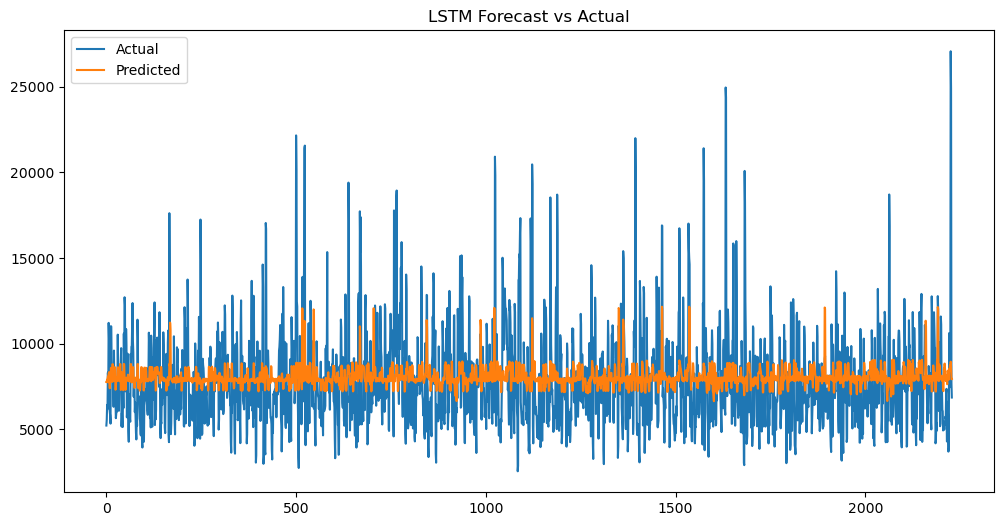

In [87]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.show()

# THE END